In [90]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [91]:
df = pd.read_parquet("data/prepared_data.parquet")

In [92]:
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,logIC50,logCC50,logSI
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


Text(0.5, 1.0, 'log(IC50) boxplot')

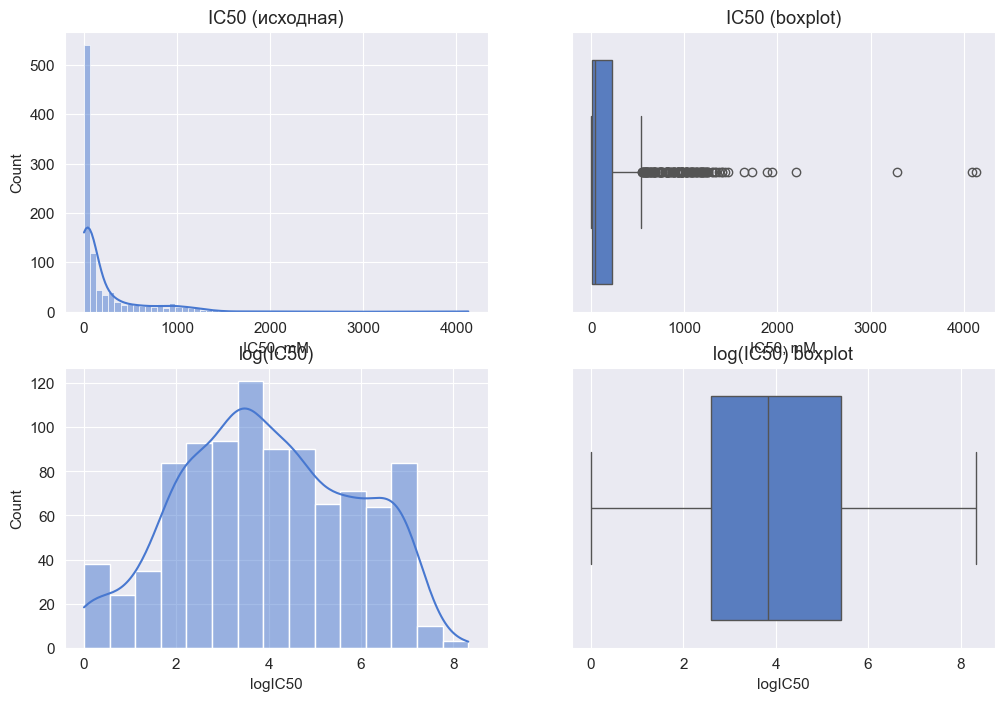

In [93]:
# Ранее мы поняли, что целевые признаки имеют ненормальное распределение, множество выбросов. На этапе EDA мы добавили в df логарифмические признаки logCC50, logIC50, logSI

# Исходная IC50
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['IC50, mM'], kde=True, ax=axes[0,0])
axes[0,0].set_title('IC50 (исходная)')
sns.boxplot(x=df['IC50, mM'], ax=axes[0,1])
axes[0,1].set_title('IC50 (boxplot)')

# Логарифмическая IC50
sns.histplot(df['logIC50'], kde=True, ax=axes[1,0])
axes[1,0].set_title('log(IC50)')
sns.boxplot(x=df['logIC50'], ax=axes[1,1])
axes[1,1].set_title('log(IC50) boxplot')

In [94]:
# Удалим целевые признаки 
targets = ['IC50, mM', 'CC50, mM', 'SI', 'logIC50', 'logCC50', 'logSI']
X = df.drop(columns=targets)

# Целевой признак (очевидно, что работать будем с логарифмическим)
y_logic50 = df['logIC50']

# Разделение на train/test
X_train, X_test, y_train_logic50, y_test_logic50  = train_test_split(X, y_logic50, test_size=0.2, random_state=42)

In [95]:
# Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
# Функция для обучения моделей
def evaluate_regression(X_train, X_test, y_train, y_test, model_name, model, param_grid):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    y_pred = grid.best_estimator_.predict(X_test)
    return {
        'model': model_name,
        'best_params': grid.best_params_,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

# Определим модели и гиперпараметры
reg_models = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}),
    'RandomForest': (RandomForestRegressor(random_state=42), {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}),
    'XGBoost': (XGBRegressor(random_state=42, verbosity=0), {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 6]})
}

In [97]:
# Регрессия IC50 LOG. Лучшие показатели у GradientBoosting
results_ic50log = []
for name, (model, params) in reg_models.items():
    res = evaluate_regression(X_train_scaled, X_test_scaled, y_train_logic50, y_test_logic50, name, model, params)
    results_ic50log.append(res)
print("Регрессия IC50 (LOG):")
for r in results_ic50log:
    print(f"{r['model']}: RMSE={r['RMSE']:.2f}, MAE={r['MAE']:.2f}, R2={r['R2']:.4f}")

Регрессия IC50 (LOG):
Ridge: RMSE=1.60, MAE=1.29, R2=0.2902
RandomForest: RMSE=1.48, MAE=1.15, R2=0.3939
GradientBoosting: RMSE=1.46, MAE=1.16, R2=0.4106
XGBoost: RMSE=1.46, MAE=1.17, R2=0.4087
